In [1]:
# Linear Neuron Model
import numpy as np
from scipy.linalg import circulant
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist
from scipy import signal
from pandas import Series
from random import gauss
import ipywidgets as widgets
from ipywidgets import interact, fixed

In [2]:
def compute_firerate(I, M, h): 
    return np.linalg.solve(I - M, h)
    
def convert_matrix(M, alpha = 0.97):
    # M = np.array(M, dtype=float) 
    eigvals = np.linalg.eigvals(M)
    max_ev = np.max(np.real(eigvals))
    print(np.max(np.real(eigvals)))
    M = (alpha / max_ev) * M

    return M

def gaussian (x, a_e, sigma_e, a_i,r):
    sigma_i = r * sigma_e
    gauss_e = (a_e / (np.sqrt(2*np.pi) * sigma_e)) * np.exp(-0.5 * (x/sigma_e) ** 2)
    gauss_i = (a_i / (np.sqrt(2*np.pi) * sigma_i)) * np.exp(-0.5 * (x/sigma_i) ** 2)

    return gauss_e - gauss_i

def recurrent_connections(N, a_e, a_i, sigma_e, r):
    x = np.arange(N)
    dist = np.minimum(x, N-x) # berechnet kürzesten periodischen Abstand auf einem Ring mit N Punkten
    kernel = gaussian(dist, a_e, sigma_e, a_i, r)
    m = circulant(kernel)

    return m

In [33]:
# N = number of neurons
N = 200
a_e = 0.9
a_i = 1.5
sigma_e = 3.0
r = 2.0

# Einheitsmatrix 
I = np.eye(N)

# Random Matrix 
M_rand = convert_matrix(np.random.randn(N, N) * 0.1)

# Gauss
M = convert_matrix(recurrent_connections(N, a_e, a_i, sigma_e, r))

# Input 
h_random = np.random.randn(N)

x = np.arange(N)
h_cos = np.cos(2 * np.pi * 6 * x / N)

h_one_neuron = np.zeros(N, dtype = float)
h_one_neuron[50] = 1

# Firerates
r1 = compute_firerate(I, M_rand, h_random)
r2 = compute_firerate(I, M_rand, h_cos)
r3 = compute_firerate(I, M, h_random)
r4 = compute_firerate(I, M, h_cos)

1.3447977600116165
0.35861075800662884


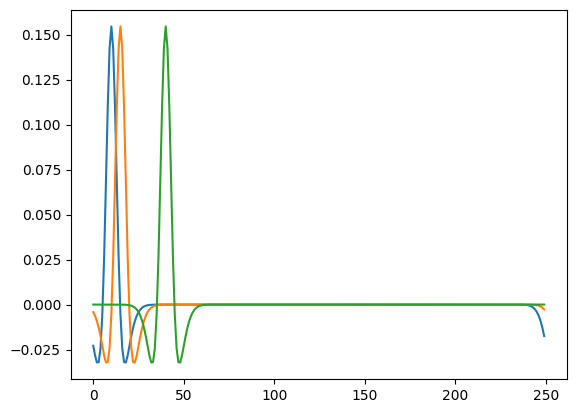

In [4]:
# in rekurrentem Netzwerk: 
# Zeile i - Gewichte von Neuron i zu allen anderen Neuronen (output connections)
# Spalte j - Gewicht von allen anderen Neuronen zu Neuron j (input connections)


# synaptischer Input-Kernel den z.B. Neuron 10 sieht
plt.plot(M.T[10])
plt.plot(M.T[15])
plt.plot(M.T[40])

# Compute Influence 
r5 = compute_firerate(I, M, h_one_neuron)
influence = r5 - h_one_neuron

plt.plot(r5); plt.title("M_gauss, h_one_neuron")
plt.plot(influence)
plt.plot(h_one_neuron); 

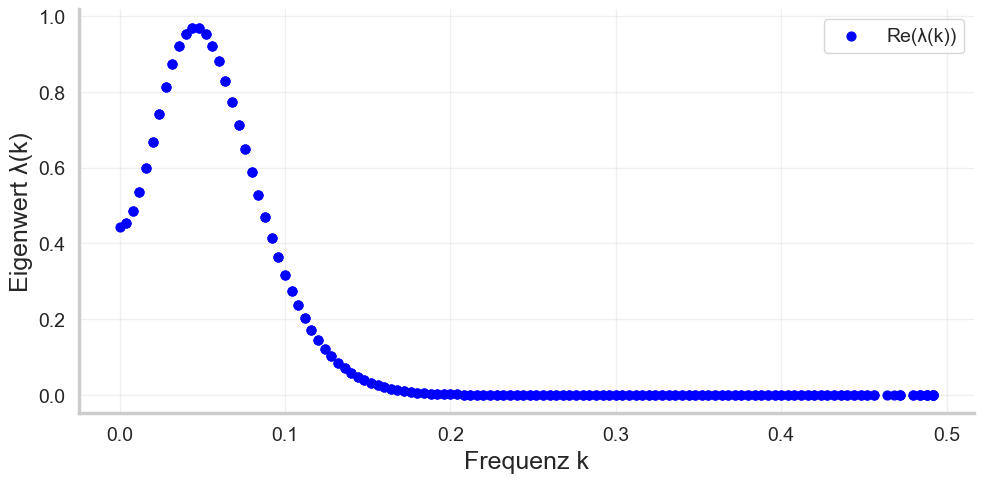

In [8]:
def eigvals_distr(M, N): 

    # die erste Zeile enthält alle Gewichte, aus denen man das Spektrum bekommt. 
    kernel = M[0, :]

    # Eigenwerte der Matrix = DFT der ersten Zeile.
    eigvals = np.fft.fft(kernel)

    # liefert Frequenzachse (k-Werte), die zu den FFT-Koeffizienten gehören.
    # FFT einer reellen Funktion ist symmetrisch -> man braucht also nur die erste Hälfte.
    freqs = np.fft.fftfreq(N)[:N//2]

    return freqs, eigvals[:N//2]

def autoval_distr(G):

    valsG,vecsG = np.linalg.eig(G)
    N=G.shape[0]
    eigenvectors= vecsG.T
    frequencies=[]
    eigenvalues=[]

    for i in range(N):
            amplitude =eigenvectors[i]

            fourierTransform = np.fft.fft(amplitude)/len(amplitude)           # Normalize amplitude

            fourierTransform = fourierTransform[range(int(len(amplitude)/2))] # Exclude sampling frequency

            tpCount     = len(amplitude)

            values      = np.arange(int(tpCount/2))

            timePeriod  = tpCount

            freq = values/timePeriod
            frequencies.append(freq[np.argmax(abs(fourierTransform ))])
            eigenvalues.append(valsG[i])


    frequencies, eigenvalues= zip(*sorted(zip(frequencies, eigenvalues)))

    return frequencies, eigenvalues

def autoval_distr2(G):

    valsG, vecsG = np.linalg.eig(G)
    N = G.shape[0]

    eigenvectors = vecsG.T  # shape: (N eigenvectors, N components)

    frequencies = []
    eigenvalues = []
    eigenvectors_list = []

    for i in range(N):
        amplitude = eigenvectors[i]

        # FFT
        fourierTransform = np.fft.fft(amplitude) / len(amplitude)
        fourierTransform = fourierTransform[:len(amplitude)//2]

        tpCount = len(amplitude)
        values = np.arange(tpCount//2)
        freq = values / tpCount

        # dominant frequency index
        dominant_freq = freq[np.argmax(abs(fourierTransform))]

        frequencies.append(dominant_freq)
        eigenvalues.append(valsG[i])
        eigenvectors_list.append(eigenvectors[i])

    idx = np.argsort(frequencies)

    frequencies = np.array(frequencies)[idx]
    eigenvalues = np.array(eigenvalues)[idx]
    eigenvectors_list = np.array(eigenvectors_list)[idx]

    return frequencies, eigenvalues, eigenvectors_list

    return np.array(frequencies), np.array(eigenvalues), np.array(eigenvectors_list)
    
Freq, Eigenval = autoval_distr(M)
real_ev = np.real(Eigenval)

fig, ax1 = plt.subplots(figsize=(10, 5))

for axis in ['top', 'bottom', 'left', 'right']:
    ax1.spines[axis].set_linewidth(2.5)

sns.despine(offset=0)

ax1.scatter(Freq, real_ev, color='blue', s=40, label='Re(λ(k))')

ax1.set_xlabel('Frequenz k', fontsize=18)
ax1.set_ylabel('Eigenwert λ(k)', fontsize=18)

ax1.tick_params(axis='both', labelsize=14, width=2)

ax1.grid(alpha=0.3)

ax1.legend(fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
def analyze_all(M, rows, col, value):
    """
    Master-Funktion:
    - erzeugt perturbierte Matrizen M_i
    - berechnet Eigenwerte + Eigenvektoren (sortiert)
    - Influence-Matrix G_i
    - Influence-Varianz
    - Eigenwert-Distanzen
    - Eigenvektor-Distanzen

    Gibt ein konsistentes results-Dict zurück.
    """

    N = M.shape[0]
    I = np.eye(N)

    # Ergebniscontainer
    results = {
        "Ms": [],
        "freqs": [],
        "eigvals": [],
        "eigvecs": [],
        "G": [],
        "variance": [],
        "dist_eigval": [],
        "dist_eigvec": [],
        "rows": rows,
        "col": col,
    }

    # ===== ORIGINAL MATRIX =====
    f0, e0, v0 = autoval_distr2(M)

    G0 = compute_influence_matrix(M, N)
    var0 = compute_variance_over_stimulus(G0)

    results["Ms"].append(M)
    results["freqs"].append(f0)
    results["eigvals"].append(e0)
    results["eigvecs"].append(v0)
    results["G"].append(G0)
    results["variance"].append(var0)

    # Distanz zu sich selbst = 0
    results["dist_eigval"].append(0.0)
    results["dist_eigvec"].append(0.0)

    # ===== PERTURBATIONEN =====
    for r in rows:

        M_i = M.copy()
        M_i.T[col][r] = value

        f_i, e_i, v_i = autoval_distr2(M_i)

        G_i = compute_influence_matrix(M_i, N)
        var_i = compute_variance_over_stimulus(G_i)

        # Distanzen
        d_val = e_i - e0

        # Eigenvektoren sind nur bis auf Vorzeichen eindeutig
        d_vec = np.abs(v_i) - np.abs(v0)

        results["Ms"].append(M_i)
        results["freqs"].append(f_i)
        results["eigvals"].append(e_i)
        results["eigvecs"].append(v_i)
        results["G"].append(G_i)
        results["variance"].append(var_i)
        results["dist_eigval"].append(d_val)
        results["dist_eigvec"].append(d_vec)

    return results

def plot_eigen_distribution(results, index):
    freqs = results["freqs"][index]
    eigs  = results["eigvals"][index]

    plt.figure(figsize=(7,5))
    plt.scatter(freqs, eigs, s=25)
    plt.title(f"Eigenvalue spectrum — Perturbation #{index}")
    plt.xlabel("k")
    plt.ylabel("Re(λ(k))")
    plt.grid(alpha=0.3)
    plt.show()

def plot_dist_eigval(results, index):
    # Hole Distanz-Vektor für die gewählte Perturbation
    dist = results["dist_eigval"][index]
    
    plt.figure(figsize=(8,5))
    plt.plot(dist, marker="o")
    plt.xlabel("Eigenvalue index")
    plt.ylabel("|λ_i − λ₀|")
    plt.title(f"Eigenvalue distance vector — Perturbation #{index}")
    plt.grid(alpha=0.3)
    plt.show()

def plot_eigenvector_distance(results, index):
    rows = results["rows"]
    d_vec = results["dist_eigvec"][index]  # Matrix oder Vektor für diesen Index

    plt.figure(figsize=(8,5))
    plt.plot(d_vec, marker="o")
    plt.xlabel("Eigenvector index")
    plt.ylabel("|v_i - v_0|")
    plt.title(f"Eigenvector distance — Perturbation #{index} (row={rows[index-1] if index>0 else 'none'})")
    plt.grid(alpha=0.3)
    plt.show()

def plot_variance(results, index):
    var = results["variance"][index]

    plt.figure(figsize=(10,5))
    plt.plot(var)
    plt.xlabel("Ort x (Neuron index)")
    plt.ylabel("Varianz der Influence")
    plt.title(f"Influence variance — Perturbation #{index}")
    plt.grid(alpha=0.3)
    plt.show()

def plot_G_heatmap(results, index):
    G = results["G"][index]

    plt.figure(figsize=(8,6))
    plt.imshow(G, cmap="viridis", aspect="auto")
    plt.colorbar(label="Influence")
    plt.title(f"Influence matrix G — Perturbation #{index}")
    plt.xlabel("Stimulusort j")
    plt.ylabel("Antwortort i")
    plt.show()

def plot_G_column(results, index, j=25):
    """
    Plottet nur die Influence-Kurve G[:, j] für einen festen Stimulusort j.
    """
    G = results["G"][index]
    influence = G[:, j]

    plt.figure(figsize=(8,5))
    plt.plot(influence, linewidth=2)
    plt.title(f"Influence G[:, {j}] – Perturbation #{index}")
    plt.xlabel("Antwortort i")
    plt.ylabel("Influence G[i, j]")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [11]:
# Perturbations (M_het = (1 + F) * M_hom

def F(N):

    sigma = 0.1
    M = 1

    # Grid für Distanzen
    xx, yy = np.meshgrid(np.arange(0, N, 1), np.arange(0, M, 1))
    dx = cdist(xx.T, xx.T)
    dx = np.minimum(dx, N * np.ones_like(dx) - dx)

    # Gaussian Random Field (1D Serie)
    series1 = [gauss(0.0, 1.0) for k in range(N)]
    grf = Series(series1)

    w = (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-dx**2 / (2 * sigma**2))

    D = int(N / 2)
    correzione = np.zeros((N, N))

    # Füge für jede Spalte die gefilterte GRF ein
    for i in range(N):
        correzione.T[i] = signal.convolve(w.T[D], grf, mode='same')

    return correzione

def perturb_M (M_hom, correzione): 
    M_het = (1 + (3)*correzione) * M_hom

    return M_het

def compute_influence_matrix (M_het, N): 
    """
    Berechnet die Influence-Matrix G: jede Spalte j ist die Antwort
    auf einen Einheitsinput am Ort j (ohne direkten Input h_j).
    """
    G = np.zeros((N, N))
    I = np.eye(N)

    for j in range(N):
        # 1. Einheitsinput an Ort j
        h = np.zeros(N)
        h[j] = 1.0

        # 2. Feuerrate r_j = (I - M)^(-1) h
        r = compute_firerate(I, M_het, h)

        # 3. Influence entfernen: subtract h
        G[:, j] = r - h

    return G

# Zeile i: Antwort des Neurons i
# Spalte j: Einfluss am Ort j 
# axis = 1, für jede Zeile i wird die Varianz über alle Orte (Spalten) j berechnet. 
def compute_variance_over_stimulus(G):
    # Varianz über Stimulusorte j (Achse 1)
    return np.var(G, axis=1)

1.146363190402504


interactive(children=(IntSlider(value=125, description='index', max=250), Output()), _dom_classes=('widget-int…

interactive(children=(IntSlider(value=125, description='index', max=250), Output()), _dom_classes=('widget-int…

interactive(children=(IntSlider(value=125, description='index', max=250), Output()), _dom_classes=('widget-int…

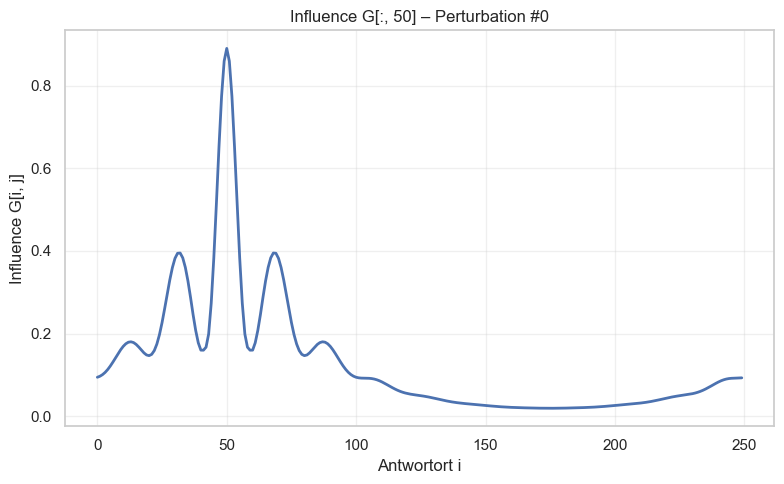

interactive(children=(IntSlider(value=125, description='index', max=250), Output()), _dom_classes=('widget-int…

<function __main__.plot_variance(results, index)>

In [12]:
M = convert_matrix(recurrent_connections(N, a_e, a_i, sigma_e, r))
results = analyze_all(M, range(N), col=200, value=1.0)

interact(plot_eigen_distribution,
         results=fixed(results),
         index=(0, len(results["eigvals"])-1))

interact(plot_dist_eigval,
         results=fixed(results),
         index=(0, len(results["dist_eigval"])-1))

#interact(plot_eigenvector_distance,
#         results=fixed(results),
#         index=(0, len(results["dist_eigvec"])-1))

interact(plot_G_heatmap,
         results=fixed(results),
         index=(0, len(results["G"])-1))

plot_G_column(results, index=0, j=50)

interact(plot_variance,
         results=fixed(results),
         index=(0, len(results["variance"])-1))


In [36]:
# perturb in a symmetric way. More than one column > multiple locations of the network. Now I just perturb e.g. column 200. CHECK
# influence should be negative on average > set values. 
# perturbation value should be in range of influence values. CHECK
# variance of connectivity and variance of influence plot. CHECK

def analyze_all_symmetric(
    M,
    pairs,
    x_percent,
):
    """
    Erweiterte Master-Funktion:
    - perturbiert gleichzeitig 3 symmetrische Paare (6 Einträge)
    - Perturbationshöhe basiert auf Influence der Ursprungsmatrix

    Parameters
    ----------
    M : ndarray
        Ursprungsmatrix
    pairs : list of tuples
        [(i1, j1), (i2, j2), (i3, j3)]
    x_percent : float
        relative Stärke der Perturbation (z.B. 0.1 = 10%)
    """

    N = M.shape[0]

    results = {
        "Ms": [],
        "freqs": [],
        "eigvals": [],
        "eigvecs": [],
        "G": [],
        "variance_influence": [],
        "variance_connectivity": [],
        "dist_eigval": [],
        "dist_eigvec": [],
        "pairs": pairs,
        "x_percent": x_percent,
    }

    # ===== ORIGINAL MATRIX =====
    f0, e0, v0 = autoval_distr2(M)

    G0 = compute_influence_matrix(M, N)
    var_i0 = compute_variance_over_stimulus(G0)
    var_c0 = compute_variance_over_stimulus(M)

    results["Ms"].append(M)
    results["freqs"].append(f0)
    results["eigvals"].append(e0)
    results["eigvecs"].append(v0)
    results["G"].append(G0)
    results["variance_influence"].append(var_i0)
    results["variance_connectivity"].append(var_c0)
    results["dist_eigval"].append(0.0)
    results["dist_eigvec"].append(0.0)

    # ===== PERTURBATION =====
    mean_influence = np.mean(G0)
    delta = x_percent * mean_influence

    M_i = M.copy()

    for (i, j) in pairs:
        M_i[i, j] += delta
        M_i[j, i] += delta  # Symmetrie

    f_i, e_i, v_i = autoval_distr2(M_i)

    G_i = compute_influence_matrix(M_i, N)
    var_influence = compute_variance_over_stimulus(G_i)
    var_connectivity = compute_variance_over_stimulus(M_i)

    d_val = e_i - e0
    d_vec = np.abs(v_i) - np.abs(v0)

    results["Ms"].append(M_i)
    results["freqs"].append(f_i)
    results["eigvals"].append(e_i)
    results["eigvecs"].append(v_i)
    results["G"].append(G_i)
    results["variance_influence"].append(var_influence)
    results["variance_connectivity"].append(var_connectivity)
    results["dist_eigval"].append(d_val)
    results["dist_eigvec"].append(d_vec)

    return results

def plot_MG_2x2(results, perturbed_index=1, cmap="viridis"):
    """
    2x2 Plot:
    Oben:    M0 | G0
    Unten:   M_perturbed | G_perturbed
    """

    M0 = results["Ms"][0]
    G0 = results["G"][0]

    Mp = results["Ms"][perturbed_index]
    Gp = results["G"][perturbed_index]

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    # Einheitliche Farbskalen
    vmin_M = min(np.min(M0), np.min(Mp))
    vmax_M = max(np.max(M0), np.max(Mp))

    vmin_G = min(np.min(G0), np.min(Gp))
    vmax_G = max(np.max(G0), np.max(Gp))

    # ===== M0 =====
    im00 = axes[0, 0].imshow(M0, cmap=cmap, vmin=vmin_M, vmax=vmax_M)
    axes[0, 0].set_title("Connectivity $M_0$")
    plt.colorbar(im00, ax=axes[0, 0], fraction=0.046)

    # ===== G0 =====
    im01 = axes[0, 1].imshow(G0, cmap=cmap, vmin=vmin_G, vmax=vmax_G)
    axes[0, 1].set_title("Influence $G_0$")
    plt.colorbar(im01, ax=axes[0, 1], fraction=0.046)

    # ===== M perturbed =====
    im10 = axes[1, 0].imshow(Mp, cmap=cmap, vmin=vmin_M, vmax=vmax_M)
    axes[1, 0].set_title("Connectivity $M_{pert}$")
    plt.colorbar(im10, ax=axes[1, 0], fraction=0.046)

    # ===== G perturbed =====
    im11 = axes[1, 1].imshow(Gp, cmap=cmap, vmin=vmin_G, vmax=vmax_G)
    axes[1, 1].set_title("Influence $G_{pert}$")
    plt.colorbar(im11, ax=axes[1, 1], fraction=0.046)

    for ax in axes.flat:
        ax.set_xlabel("j")
        ax.set_ylabel("i")

    plt.tight_layout()
    plt.show()

def plot_variances_2x2(results):
    """
    2x2 Plot:
    Oben:    Var(M0) | Var(G0)
    Unten:   Var(Mp) | Var(Gp)
    """

    var_M0 = results["variance_connectivity"][0]
    var_G0 = results["variance_influence"][0]

    var_Mp = results["variance_connectivity"][1]
    var_Gp = results["variance_influence"][1]

    fig, axes = plt.subplots(2, 2, figsize=(10, 6))

    vmax_M = max(var_M0.max(), var_Mp.max())
    vmax_G = max(var_G0.max(), var_Gp.max())

    # ===== Connectivity Varianz =====
    axes[0, 0].plot(var_M0)
    axes[0, 0].set_title("Varianz Connectivity $M_0$")

    axes[1, 0].plot(var_Mp)
    axes[1, 0].set_title("Varianz Connectivity $M_{pert}$")

    # ===== Influence Varianz =====
    axes[0, 1].plot(var_G0)
    axes[0, 1].set_title("Varianz Influence $G_0$")

    axes[1, 1].plot(var_Gp)
    axes[1, 1].set_title("Varianz Influence $G_{pert}$")

    for ax in axes.flat:
        ax.set_xlabel("Neuron i")
        ax.set_ylabel("Varianz")
        ax.grid(True)

    plt.tight_layout()
    plt.show()

import matplotlib.pyplot as plt
import numpy as np

def plot_mean_and_variance_MG(results, index):
    """
    2x2 Plot:
    - oben links:   Mean Connectivity
    - oben rechts:  Mean Influence
    - unten links:  Var Connectivity
    - unten rechts: Var Influence
    """

    M = results["Ms"][index]
    G = results["G"][index]

    mean_M = np.mean(M, axis=1)
    mean_G = np.mean(G, axis=1)

    var_M = results["variance_connectivity"][index]
    var_G = results["variance_influence"][index]

    neurons = np.arange(len(mean_M))

    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)

    # ===== Mean Connectivity =====
    axes[0, 0].plot(neurons, mean_M, linewidth=2)
    axes[0, 0].set_title("Mean Connectivity")
    axes[0, 0].set_ylabel("Mean over j")
    axes[0, 0].grid(True)

    # ===== Mean Influence =====
    axes[0, 1].plot(neurons, mean_G, linewidth=2)
    axes[0, 1].set_title("Mean Influence")
    axes[0, 1].grid(True)

    # ===== Var Connectivity =====
    axes[1, 0].plot(neurons, var_M, linewidth=2)
    axes[1, 0].set_title("Variance Connectivity")
    axes[1, 0].set_xlabel("Neuron i")
    axes[1, 0].set_ylabel("Variance over j")
    axes[1, 0].grid(True)

    # ===== Var Influence =====
    axes[1, 1].plot(neurons, var_G, linewidth=2)
    axes[1, 1].set_title("Variance Influence")
    axes[1, 1].set_xlabel("Neuron i")
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

In [37]:
def influence_stats(M):
    N = M.shape[0]
    G = compute_influence_matrix(M, N)

    print(f"Average influence: {np.mean(G):.6f}")
    print(f"Min influence:     {np.min(G):.6f}")
    print(f"Max influence:     {np.max(G):.6f}")
    print(f"Std influence:     {np.std(G):.6f}")

    return G

G = influence_stats(M)

Average influence: -0.003094
Min influence:     -0.903291
Max influence:     1.006020
Std influence:     0.307877


0.35861075800662884


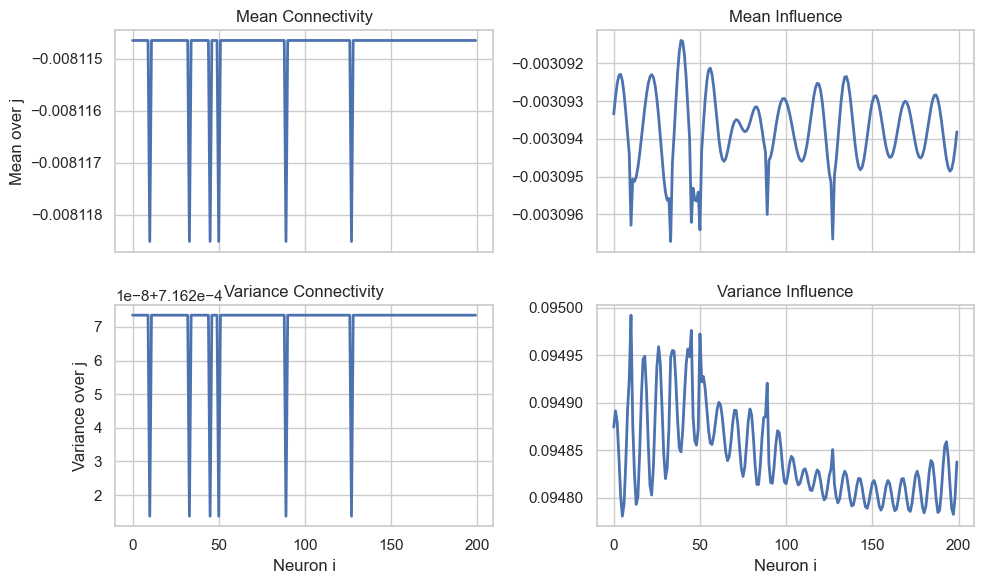

In [40]:
M = convert_matrix(recurrent_connections(N, a_e, a_i, sigma_e, r))

pairs = [(10, 50), (33, 127), (89, 45)]

results2 = analyze_all_symmetric(M, pairs, 0.25)

# plot_MG_2x2(results2)
plot_mean_and_variance_MG(results2, 1)

In [41]:
def random_symmetric_pairs(N, n_pairs=3, seed=None):
    """
    Erzeugt n_pairs zufällige, eindeutige Indexpaare (i, j) mit i != j.
    """
    rng = np.random.default_rng(seed)
    pairs = set()

    while len(pairs) < n_pairs:
        i = rng.integers(0, N)
        j = rng.integers(0, N)
        if i != j:
            pair = tuple(sorted((i, j)))
            pairs.add(pair)

    return list(pairs)

from ipywidgets import interact, IntSlider

def interactive_mean_variance_plot(results_list):
    """
    Interaktiver Plot für mehrere Perturbationen.
    """

    def _plot(choice):
        plot_mean_and_variance_MG(results_list[choice], index=1)

    interact(
        _plot,
        choice=IntSlider(min=0, max=len(results_list)-1, step=1, value=0)
    )

In [43]:
pairs1 = random_symmetric_pairs(N)
pairs2 = random_symmetric_pairs(N)
pairs3 = random_symmetric_pairs(N)

results1 = analyze_all_symmetric(M, pairs1, 0.5)
results2 = analyze_all_symmetric(M, pairs2, 0.5)
results3 = analyze_all_symmetric(M, pairs3, 0.5)

interactive_mean_variance_plot([results1, results2, results3])

interactive(children=(IntSlider(value=0, description='choice', max=2), Output()), _dom_classes=('widget-intera…

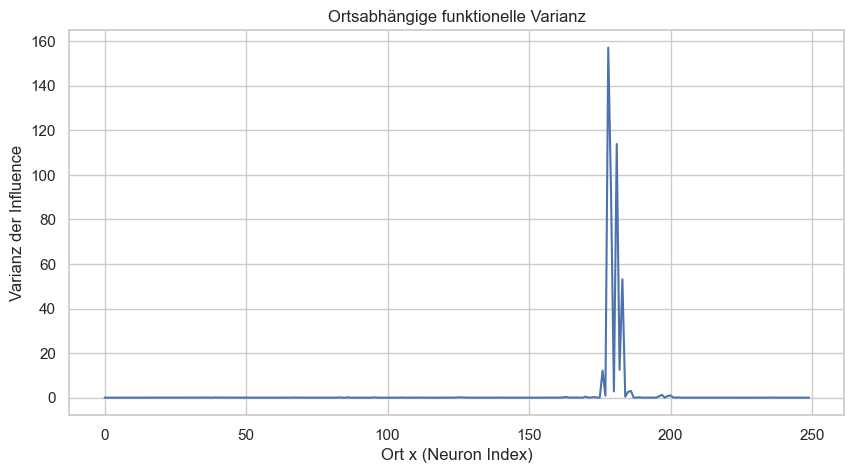

In [9]:
# 1. Heterogenität erzeugen
corr = F(N)
M_het = perturb_M(M, corr)
         
# 2. Influence-Matrix berechnen
G = compute_influence_matrix(M_het, N)

# 3. Varianz über Stimulusorte
var_x = compute_variance_over_stimulus(G)

# 4. Plotten
plt.figure(figsize=(10,5))
plt.plot(var_x)
plt.xlabel("Ort x (Neuron Index)")
plt.ylabel("Varianz der Influence")
plt.title("Ortsabhängige funktionelle Varianz")
plt.show()

# perturb just one neuron to see what the effect is on the influence. Modify M in just one place. 
# Check if eigenvalues before (without perturbation) the same as the perturb one -> is just one affected or more?

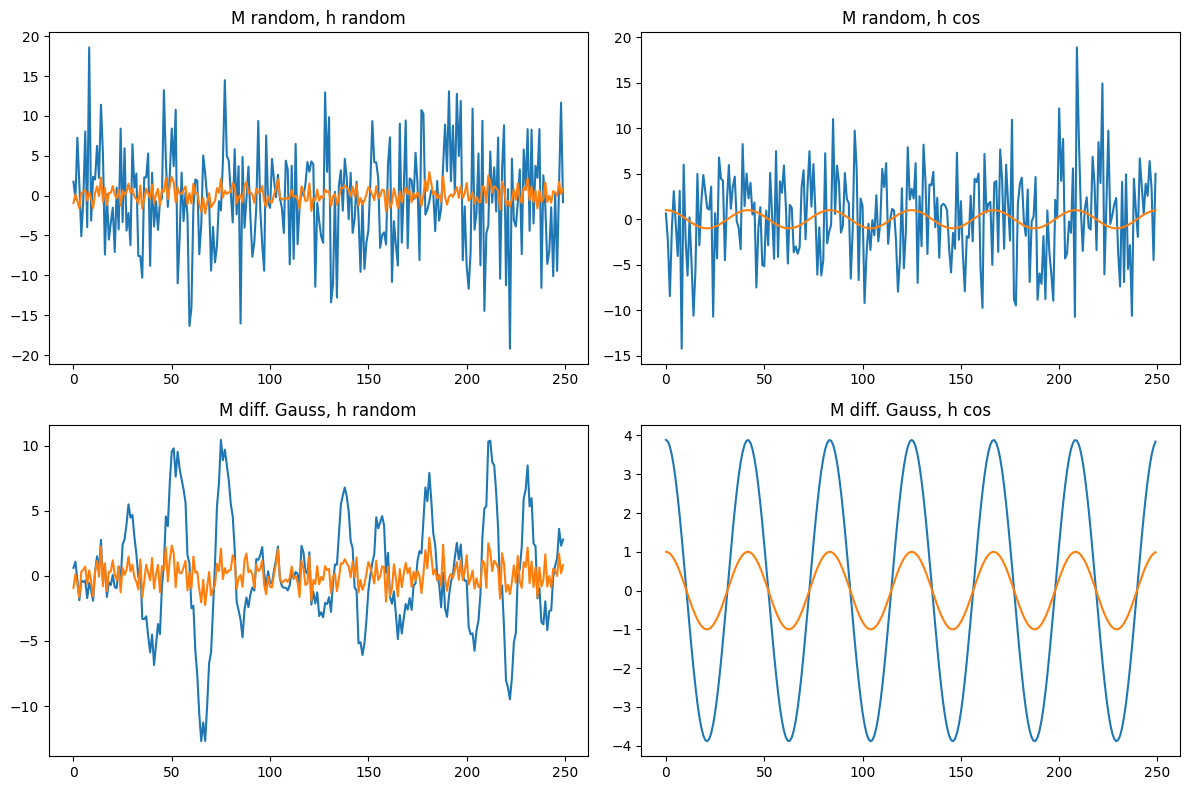

In [5]:
# Plot
plt.figure(figsize=(12,8))

plt.subplot(2, 2, 1)
plt.plot(r1); plt.title("M random, h random")
plt.plot(h_random); 

plt.subplot(2,2,2)
plt.plot(r2); plt.title("M random, h cos")
plt.plot(h_cos); 

plt.subplot(2,2,3)
plt.plot(r3); plt.title("M diff. Gauss, h random")
plt.plot(h_random); 

plt.subplot(2,2,4)
plt.plot(r4); plt.title("M diff. Gauss, h cos")
plt.plot(h_cos); 

plt.tight_layout()
plt.show()

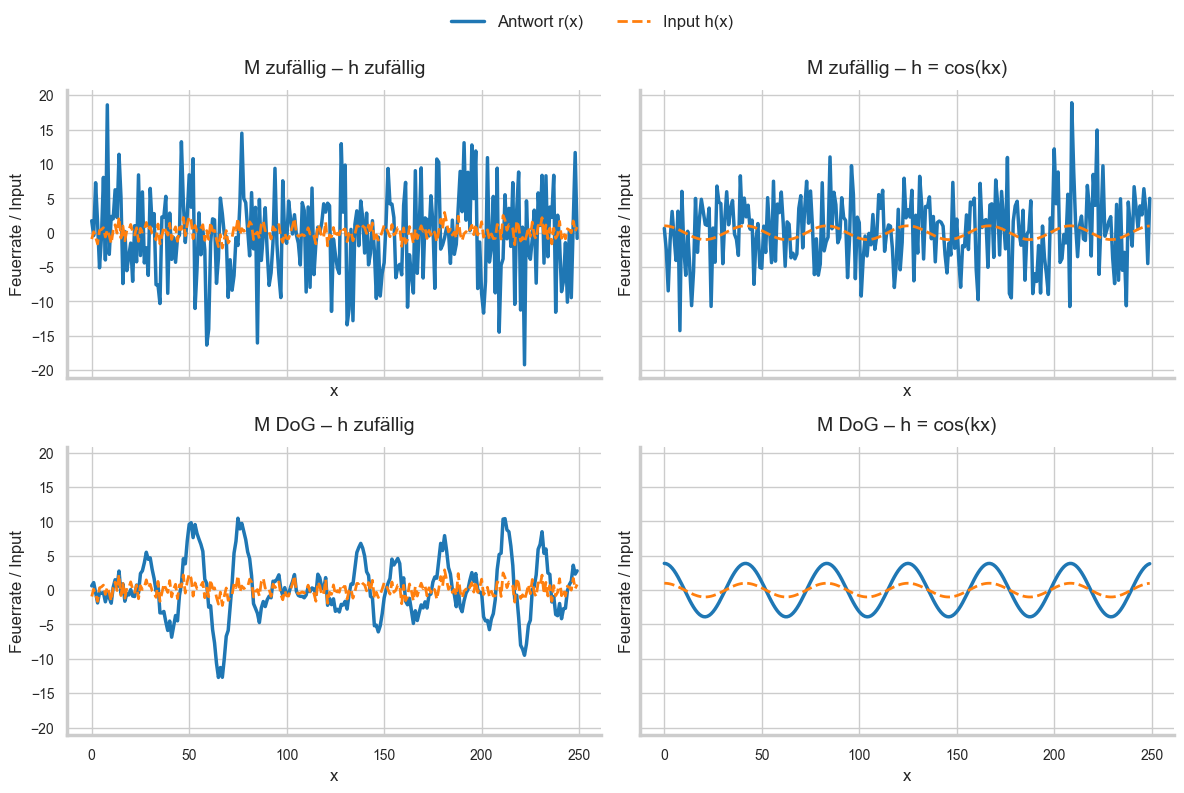

In [6]:
sns.set(style="whitegrid")

fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

titles = [
    "M zufällig – h zufällig",
    "M zufällig – h = cos(kx)",
    "M DoG – h zufällig",
    "M DoG – h = cos(kx)"
]

responses = [r1, r2, r3, r4]
inputs = [h_random, h_cos, h_random, h_cos]
colors = ["#1f77b4", "#ff7f0e"]  # Blau für r, Orange für h

for ax, r, h, title in zip(axs.flat, responses, inputs, titles):
    ax.plot(r, color=colors[0], lw=2.5, label="Antwort r(x)")
    ax.plot(h, color=colors[1], lw=2.0, ls="--", label="Input h(x)")
    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel("x", fontsize=12)
    ax.set_ylabel("Feuerrate / Input", fontsize=12)
    ax.tick_params(axis="both", labelsize=10, width=1.5)
    
    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(2.5)
        
    sns.despine(ax=ax)

# Gemeinsame Legende oben hinzufügen
handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, fontsize=12, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Platz für die Legende
plt.show()

1.146363190402504
1.146363190402504
1.146363190402504
1.146363190402504


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/matplotlib/collections.py:193: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


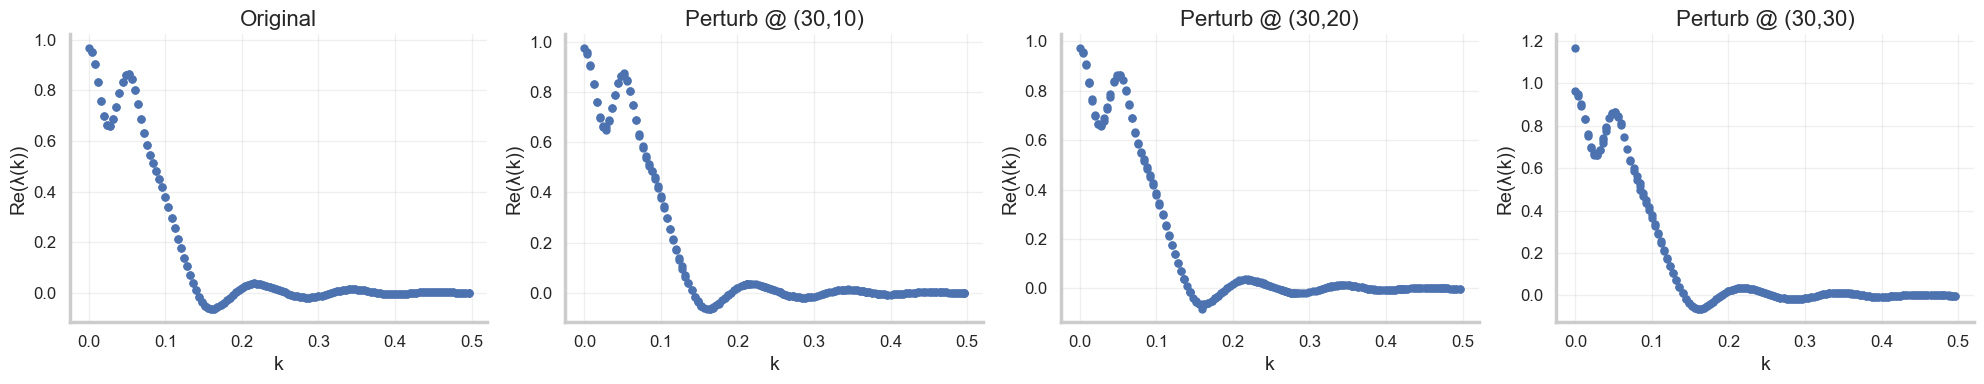

Distanz Original vs M_4: 0.0654475075759709
Distanz Original vs M_5: 0.16555605901122444
Distanz Original vs M_6: 0.351416533519631


In [9]:
M = convert_matrix(recurrent_connections(N, a_e, a_i, sigma_e, r))
M_4 = convert_matrix(recurrent_connections(N, a_e, a_i, sigma_e, r))
M_5 = convert_matrix(recurrent_connections(N, a_e, a_i, sigma_e, r))
M_6 = convert_matrix(recurrent_connections(N, a_e, a_i, sigma_e, r))

# All versions of the same basis matrix, perturbations in same column, but different locations. 
M_4.T[30][10] = 1
M_5.T[30][20] = 1
M_6.T[30][30] = 1

# Freqeuencies and eigenvalues for homogenous and perturbed matrices. 
f1, e1 = autoval_distr(M)
f2, e2 = autoval_distr(M_4)
f3, e3 = autoval_distr(M_5)
f4, e4 = autoval_distr(M_6)

# Convert tuples → NumPy arrays
f1, e1 = np.array(f1), np.array(e1)
f2, e2 = np.array(f2), np.array(e2)
f3, e3 = np.array(f3), np.array(e3)
f4, e4 = np.array(f4), np.array(e4)


# 1. Alle 4 nebeneinander plotten. 
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

matrices = [(f1, e1, "Original"),
            (f2, e2, "Perturb @ (30,10)"),
            (f3, e3, "Perturb @ (30,20)"),
            (f4, e4, "Perturb @ (30,30)")]

for ax, (freqs, eigs, title) in zip(axes, matrices):

    # Thick axes
    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(2.5)

    sns.despine(offset=0)

    ax.scatter(freqs, eigs, s=25)
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("k", fontsize=14)
    ax.set_ylabel("Re(λ(k))", fontsize=14)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='both', labelsize=12, width=2)

plt.tight_layout()
plt.show()

# 2. Quantify changes in eigenvalues

def eig_distance(e_orig, e_new):
    return np.linalg.norm(e_new - e_orig)
    
d_4 = eig_distance(e1, e2)
d_5 = eig_distance(e1, e3)
d_6 = eig_distance(e1, e4)

print("Distanz Original vs M_4:", d_4)
print("Distanz Original vs M_5:", d_5)
print("Distanz Original vs M_6:", d_6)

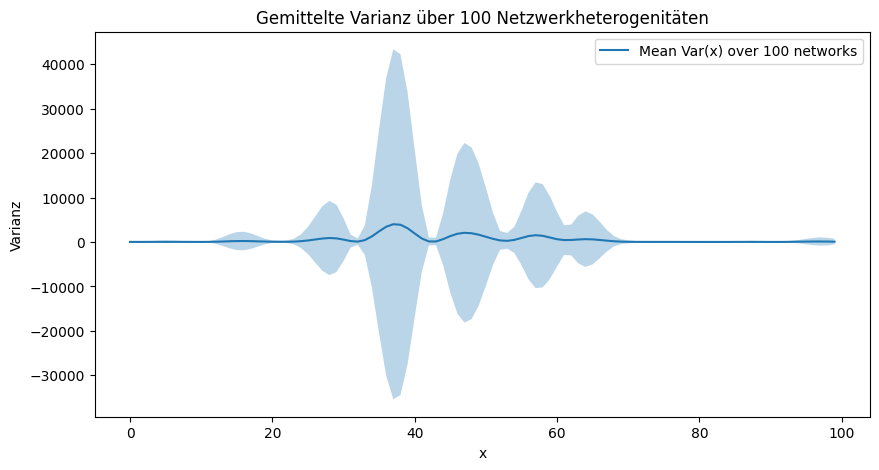

In [23]:
# Gemittelte Varianz über N Realisierungen der Heterogenität - z.B. für ein generisches Modell

def compute_mean_variance_over_networks(M_hom, N, n_real=100):

    all_var_x = []

    I_matrix = np.eye(N)

    for k in range(n_real):
        # Zufällige Heterogenität
        corr = F(N)
        M_het = perturb_M(M_hom, corr)

        # Influence-Matrix
        G = compute_influence_matrix(M_het, N)

        # funktionelle Varianz über Stimulusorte
        var_x = np.var(G, axis=1)
        all_var_x.append(var_x)

    all_var_x = np.array(all_var_x)

    # Mittelwert + Standardabweichung
    mean_var = np.mean(all_var_x, axis=0)
    std_var = np.std(all_var_x, axis=0)

    return mean_var, std_var, all_var_x

mean_var, std_var, all_var_x = compute_mean_variance_over_networks(M, N=100, n_real=100)

plt.figure(figsize=(10,5))
plt.plot(mean_var, label="Mean Var(x) over 100 networks")
plt.fill_between(np.arange(100), mean_var-std_var, mean_var+std_var, alpha=0.3)
plt.legend()
plt.xlabel("x")
plt.ylabel("Varianz")
plt.title("Gemittelte Varianz über 100 Netzwerkheterogenitäten")
plt.show()

In [ ]:
# THEORIE

# sigma_i > sigma_e sein!
# difference of gaussians for modelling receptive fields
# sigma is the width of the curve. 
# small sigma, small peak -> local -> for a very specific stimulus
# big sigma, wide distribution -> global -> stimulus is not as specific 
# a_e, a_i = amplitudes for inhibition and excitement
# sigma_i > sigma_e: Hemmung wirkt breiter als Erregung wie in "center-surround" Strukturen des visuellen Systems
# positiver Peak im Zentrum und negative Ränder (laterale Hemmung). 
# wenn a_e > a_i: das Zentrum dominiert -> starke Aktivierung, sonst schwächere Antwort.

# FOURIER

# zirkulante Matrix wird diagonalisiert durch die diskrete Fouriertransformation (DFT). 
# M = F^(-1) * LAMBDA * F
# F == DFT-Matrix und LAMDA == diagonal (quadratische Matrix alle Werte aus Hauptdiagonale null)
# mit Eigenwerten lambda(k).
# Eigenvektoren sind komplexe Sinuswellen mit v(x) = e^((-i*2*pi*k*n)/N)) für k = 0, 1, ..., N-1
# k ist die räumliche Frequenz z.B. k = 0 ist konstantes Muster über den Raum
# Wenn du also N Neuronen gleichmäßig über Raum x∈[−0.5,0.5] verteilst, dann steht:
# k = 0 -> gleichmäßige Aktivität über alle Neuronen
# k = 1 -> eine Welle mit einer Periode über den Raum usw. 
# Jeder dieser Fourier-Moden ist ein Eigenvektor von M, der zugehörige Eigenwert ergibt sich 
# durch Fouriertransformation des Kernels. 

# WIE IST M AUFGEBAUT

# Zeilen -> empfangende Neuronen; Spalten -> sendende Neuronen
# die erste Zeile von M heißt kernel, jede weitere Zeile ist eine zyklische Verschiebung davon. 
# -> zirkulante Matrix. 
# Das entspricht einem Ring von Neuronen: 
# Jedes Neuron empfängt denselben räumlichen Verbindungskern (DoG) - nur zentriert auf die eigene Position.
# Bei zirkulanten Matrizen gilt: ihre Eigenvektoren sind Fourier-Moden (e^ikx)
# d.h. jede räumliche Sinus ist eine Eigenfunktion von M. 
# Der zugehörige Eigenwert gibt an, wie stark diese Welle verstärkt oder gedämpft wird.